In [1]:
# Import libraries
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Data
DATA_PATH = Path("../data/raw/online_retail_listing.csv")
df_raw = pd.read_csv(DATA_PATH, encoding='ISO-8859-1', sep=';', decimal=',')
df_clean = df_raw.copy()
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,1.12.2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,1.12.2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,1.12.2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,1.12.2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.12.2009 07:45,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,4.12.2011 13:00,8.25,14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,4.12.2011 13:00,4.95,14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,4.12.2011 13:15,1.65,16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,4.12.2011 13:15,2.89,16931.0,United Kingdom


In [3]:
#Initial data preview
print("Head")
display(df_clean.head())
print("\n"*4)
print("Tail")
display(df_clean.tail())

Head


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,1.12.2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,1.12.2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,1.12.2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,1.12.2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.12.2009 07:45,1.25,13085.0,United Kingdom







Tail


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1048570,580501,23284,DOORMAT KEEP CALM AND COME IN,2,4.12.2011 13:00,8.25,14546.0,United Kingdom
1048571,580501,22507,MEMO BOARD RETROSPOT DESIGN,3,4.12.2011 13:00,4.95,14546.0,United Kingdom
1048572,580502,22469,HEART OF WICKER SMALL,3,4.12.2011 13:15,1.65,16931.0,United Kingdom
1048573,580502,23489,VINTAGE BELLS GARLAND,2,4.12.2011 13:15,2.89,16931.0,United Kingdom
1048574,580502,23046,PAPER LANTERN 9 POINT DELUXE STAR,1,4.12.2011 13:15,6.65,16931.0,United Kingdom


In [4]:
print("DataFrame Info \n")
df_clean.info()

DataFrame Info 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   Customer ID  811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [5]:
print("Descriptive Statistics for all columns \n")
display(df_raw.describe(include='all'))

Descriptive Statistics for all columns 



,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1048575,1048575,1044203,1.048575e+06,1048575,1.048575e+06,811893.000000,1048575
unique,52961,5304,5697,NaN,47046,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,6.12.2010 16:57,NaN,NaN,United Kingdom
freq,1350,5781,5875,NaN,1350,NaN,NaN,963819
mean,NaN,NaN,NaN,9.957525e+00,NaN,4.627346e+00,15324.712265,NaN
std,NaN,NaN,NaN,1.335187e+02,NaN,1.228024e+02,1697.033034,NaN
min,NaN,NaN,NaN,-7.421500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13971.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15260.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16795.000000,NaN


In [6]:
print("Missing Value Counts \n")
missing_values = df_raw.isnull().sum()
print(missing_values[missing_values > 0].sort_values(ascending=False))

Missing Value Counts 

Customer ID    236682
Description      4372
dtype: int64


In [7]:
print(f"Duplicate Row Check \n")
print(f"Found {df_raw.duplicated().sum()} duplicated rows.")

Duplicate Row Check 

Found 34150 duplicated rows.


### Initial Diagonsis
1. Data Integrity error: The dataset contains logically impossible values, such as negative Quantity and Price, which could be canceled orders or data entry errors. There are also thousands of records with a Price of zero.<br><br>
2. Severe Missing Data: Over 22% of records are missing a Customer Id. Since goal is a customer-centric analysis (RFM, LTV) these records are unusable for our primary purpose.<br><br>
3. Data Contamination: There are over 34,000 duplciate transaction records that will skew any frequency or monetary calculations.<br><br>
4. Incorrect Data Types: Key columns like InvoiceDate (currently object) and Customer ID (currently float64) are not in their correct, usable formats.<br><br>
5. Geographic Concentration: The business context is overwhelmingly dominated by the United Kingdom(87%), which we must account for in analysis to avoid biased conclusions.<br><br>

In [8]:
print(f"Original shape of the DataFrame: {df_clean.shape}")

Original shape of the DataFrame: (1048575, 8)


In [9]:
# Remove canceled orders (invoices starting with 'C')
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C', na=False)]
print(f"Shape after removing canceled orders: {df_clean.shape}")

Shape after removing canceled orders: (1029314, 8)


In [10]:
# Remove rows with non-positive quantity and price of zero
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
print(f"Shape after removing non-positive quantities and items priced zero: {df_clean.shape}")

Shape after removing non-positive quantities and items priced zero: (1023143, 8)


In [11]:
# Handle missing customer id and description
df_clean.dropna(subset=['Customer ID'], inplace=True)
df_clean.dropna(subset=['Description'], inplace=True)
print(f"Shape after dropping missing Customer IDs and Description: {df_clean.shape}")

Shape after dropping missing Customer IDs and Description: (793309, 8)


In [12]:
# Remove Duplicate Rows
df_clean.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df_clean.shape}")

Shape after removing duplicates: (767369, 8)


In [13]:
# Correct Data Types
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='mixed', dayfirst=True, errors='coerce')
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int).astype(str)
display(df_clean.dtypes)

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
dtype: object

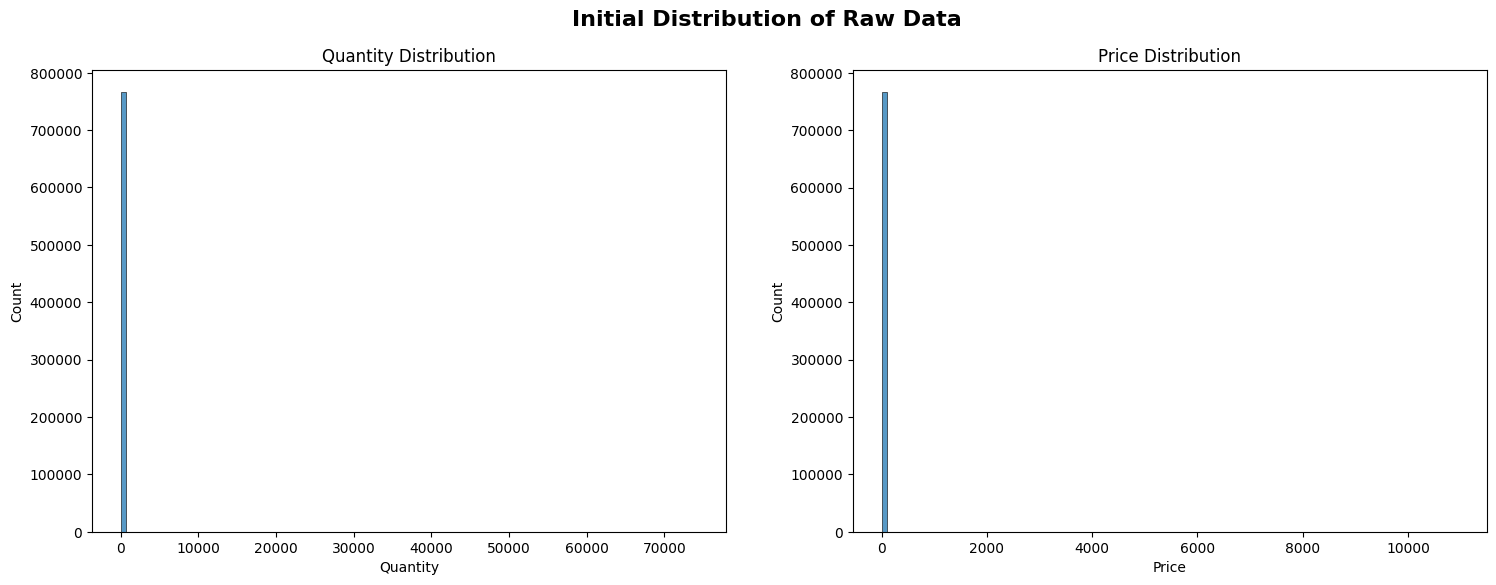

Initial Skewness (from Raw Data)
Quantity Skewness: 384.39
Price Skewness: 239.92


In [14]:
# Assess Data Skewness
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Initial Distribution of Raw Data', fontsize=16, fontweight='bold')

sns.histplot(df_clean['Quantity'], bins=100, ax=axes[0]).set_title('Quantity Distribution')
sns.histplot(df_clean['Price'], bins=100, ax=axes[1]).set_title('Price Distribution')
plt.show()

print("Initial Skewness (from Raw Data)")
print(f"Quantity Skewness: {df_clean['Quantity'].skew():.2f}")
print(f"Price Skewness: {df_clean['Price'].skew():.2f}")

In [15]:
print("Handling Outliers using the IQR method")

for col in ['Quantity', 'Price']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outlier_count = df_clean[df_clean[col] > upper_bound].shape[0]
    print(f"Found {outlier_count} outliers in '{col}' (values > {upper_bound:.2f})")
    
    # Cap the outliers
    df_clean[col] = df_clean[col].clip(upper=upper_bound)
    print(f"Capped outliers in '{col}'.")

print("\nOutlier handling complete.")

Handling Outliers using the IQR method
Found 50313 outliers in 'Quantity' (values > 27.00)
Capped outliers in 'Quantity'.
Found 64667 outliers in 'Price' (values > 7.50)
Capped outliers in 'Price'.

Outlier handling complete.


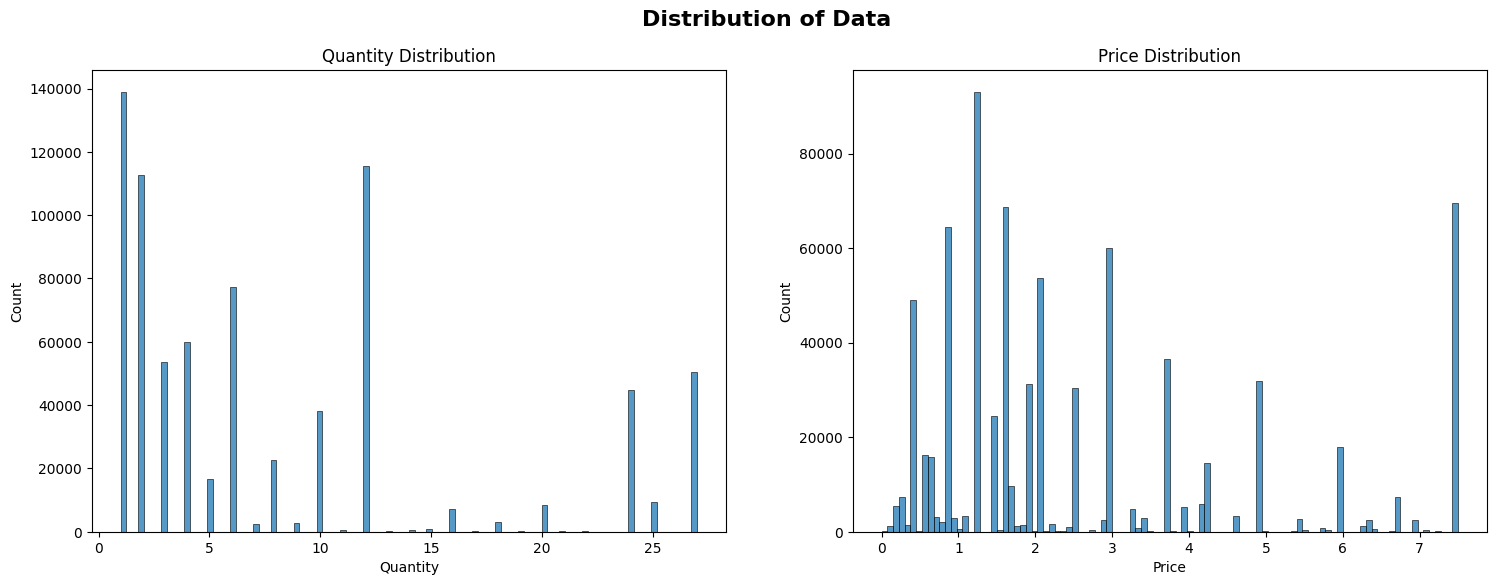

Skewness (from Raw Data)
Quantity Skewness: 1.18
Price Skewness: 1.13


In [16]:
# Assess Data Skewness
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribution of Data', fontsize=16, fontweight='bold')

sns.histplot(df_clean['Quantity'], bins=100, ax=axes[0]).set_title('Quantity Distribution')
sns.histplot(df_clean['Price'], bins=100, ax=axes[1]).set_title('Price Distribution')
plt.show()

print("Skewness (from Raw Data)")
print(f"Quantity Skewness: {df_clean['Quantity'].skew():.2f}")
print(f"Price Skewness: {df_clean['Price'].skew():.2f}")

### Feature Engineering

In [17]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.month
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,InvoiceMonth,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",27,2009-12-01 07:45:00,2.10,13085,United Kingdom,56.7,12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,12,Tuesday,7


In [18]:
# Save preprocessed file
df_clean.to_csv('../data/processed/cleaned_data.csv', index= False)